# Notebook 03 - Body Impact Sound (FEM)

Author: Stellars Henson<br>
Approach: the acoustic signature of the corridor incident - the "thump" of a body striking the elevator door, as heard by a microphone 1 m away. The body is given a real 3D shape and is allowed to **deform**: a finite-element model computes how the torso squashes on impact. The microphone hears two things summed - the low thump of the air the deforming body pushes, and a brief, high, textured burst of air squeezed out of the closing wall-body gap.

The modelling lives in the `henryk_simulations.corridor.bodyfem` library; this notebook is a thin client over its staged functions.

## Model decisions

- **Real body mesh, deformed by FEM.** The upper torso of the BodyParts3D skin model is isolated, voxelised into a tetrahedral solid, and given a 3D linear-elastic finite-element model (scikit-fem). An eigensolve gives its soft-tissue deformation modes.
- **The body does not produce sound - the pushed air does.** The body is a moving boundary. The impact deforms the torso, the deforming surface pushes air, and the pushed air is what reaches the microphone.
- **The thorax is compressible.** It is an air-filled bag (the lungs), so the impact squash genuinely changes its volume and the chest wall works as a bellows.
- **The uneven body surface textures the sound.** The surface is not smooth - ribs, the spine, clothing folds. That roughness grains the contact force, so the thump is not a pure tone. And the air trapped in the closing gap escapes through the irregular gap as a broadband, textured burst, far higher in pitch than the thump.
- **Rigid wall.** The elevator door is rigid - it does not flex and does not radiate.


In [1]:
%load_ext autoreload
%autoreload 2

# Imports
from __future__ import annotations

import dataclasses
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import meshio
from scipy.io import wavfile

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Project library - the FEM body-sound modelling lives in the corridor submodule
from henryk_simulations.corridor.bodyfem import (
    BodyFEMConfig,
    air_escape,
    ensure_body_mesh,
    impact_response,
    isolate_upper_torso,
    load_body_mesh,
    radiate_modes,
    solve_body_fem,
    solve_modes,
    sound_levels,
    voxelise_torso,
)

# the closing-velocity envelope is taken from notebook 01's kinematics
from henryk_simulations.corridor.choreography import ChoreographyConfig, solve_envelope

console = Console()
sns.set_theme(style="whitegrid", context="notebook")


def equal_3d(ax, pts):
    """Give a 3D axis an equal-aspect cube around a point cloud."""
    ext = np.ptp(pts, axis=0).max()
    mid = pts.mean(axis=0)
    ax.set_xlim(mid[0] - ext / 2, mid[0] + ext / 2)
    ax.set_ylim(mid[1] - ext / 2, mid[1] + ext / 2)
    ax.set_zlim(mid[2] - ext / 2, mid[2] + ext / 2)
    ax.set_box_aspect((1, 1, 1))

2026-05-18 13:16:24.780 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)


## Configuration

`BodyFEMConfig` is the single configuration object for this notebook - the body mesh and upper-torso isolation, the impact, the finite-element model, the acoustics, the squeezed-air escape, and the surface roughness. Every section below reads from it.


In [3]:
CFG = BodyFEMConfig()
FIG_DIR = Path("..") / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg_tbl = Table(show_header=False, box=None, padding=(0, 2))
cfg_tbl.add_column("field", style="bold cyan")
cfg_tbl.add_column("value")
for f in dataclasses.fields(CFG):
    cfg_tbl.add_row(f.name, f"[white]{getattr(CFG, f.name)}[/white]")
console.print(Panel(cfg_tbl, title="[bold green]BodyFEMConfig[/bold green]",
                    border_style="green"))


╭───────────────────────────────────────────────── BodyFEMConfig ─────────────────────────────────────────────────╮
│   mesh_path             data/external/body_mesh/body-skin.obj                                                   │
│   stl_path              data/external/body_mesh/FMA7163-skin.stl                                                │
│   mesh_url              https://raw.githubusercontent.com/Kevin-Mattheus-Moerman/BodyParts3D/main/assets/Bod…   │
│   stl_unit_scale        0.001                                                                                   │
│   decimate_voxel        0.032                                                                                   │
│   torso_z_lo_frac       0.62                                                                                    │
│   torso_z_hi_frac       0.84                                                                                    │
│   torso_x_halfwidth     0.2                                                                                     │
│   m_eff                 30.0                                                                                    │
│   v_close               2.74                                                                                    │
│   restitution           0.25                                                                                    │
│   contact_time          0.03                                                                                    │
│   voxel_size            0.022                                                                                   │
│   youngs_modulus        500000.0                                                                                │
│   poisson               0.35                                                                                    │
│   density               1000.0                                                                                  │
│   modal_damping         0.2                                                                                     │
│   n_modes               12                                                                                      │
│   air_rho               1.2                                                                                     │
│   air_c                 343.0                                                                                   │
│   mic_distance          1.0                                                                                     │
│   sample_rate           44100                                                                                   │
│   t_max                 0.3                                                                                     │
│   contact_patch_area    0.035                                                                                   │
│   gap_squeeze_start     0.006                                                                                   │
│   gap_seal              0.0015                                                                                  │
│   escape_band_lo        300.0                                                                                   │
│   escape_band_hi        6000.0                                                                                  │
│   escape_seed           0                                                                                       │
│   surface_roughness     0.25                                                                                    │
│   roughness_seed        1                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Data Acquisition

The model needs the body-skin mesh. The committed `body-skin.obj` is a decimated working copy; if it is absent, `ensure_body_mesh` downloads the full-resolution BodyParts3D skin STL (FMA7163, ~79 MB) and decimates it by vertex clustering. The raw STL is not committed - its source and licence are in `data/external/body_mesh/README.md`.


In [4]:
mesh_path = ensure_body_mesh(CFG)
console.print(Panel(
    f"working mesh [cyan]{CFG.mesh_path}[/cyan] "
    f"[dim]({mesh_path.stat().st_size / 1024:.0f} KB)[/dim]",
    title="[bold green]Body mesh ready[/bold green]", border_style="green"))
console.print(
    f"[dim]raw STL, downloaded only if the working mesh is absent:[/dim] "
    f"[cyan]{CFG.mesh_url}[/cyan]"
)


╭──────────────────────────────────────────────── Body mesh ready ────────────────────────────────────────────────╮
│ working mesh data/external/body_mesh/body-skin.obj (374 KB)                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

raw STL, downloaded only if the working mesh is absent: 
https://raw.githubusercontent.com/Kevin-Mattheus-Moerman/BodyParts3D/main/assets/BodyParts3D_data/stl/FMA7163.stl

## The Body Mesh and Torso

The radiating surface is a real 3D human body. The BodyParts3D skin model - an MRI-derived anatomical surface, already decimated to a workable triangle count - is loaded, and the **upper torso is isolated** from it: the band of the body that struck the wall, with the arms trimmed away. The isolated torso is saved to `data/external/body_mesh/upper-torso.obj`; it is the shape the finite-element model is built on.


                     Body mesh -> isolated upper torso                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Mesh                         ┃ Vertices ┃ Triangles ┃            Measure ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ BodyParts3D skin (decimated) │     3128 │     11702 │        1.64 m tall │
│ upper torso (isolated)       │      826 │      3298 │ 24.1 L hull volume │
└──────────────────────────────┴──────────┴───────────┴────────────────────┘

isolated upper torso saved to ../data/external/body_mesh/upper-torso.obj

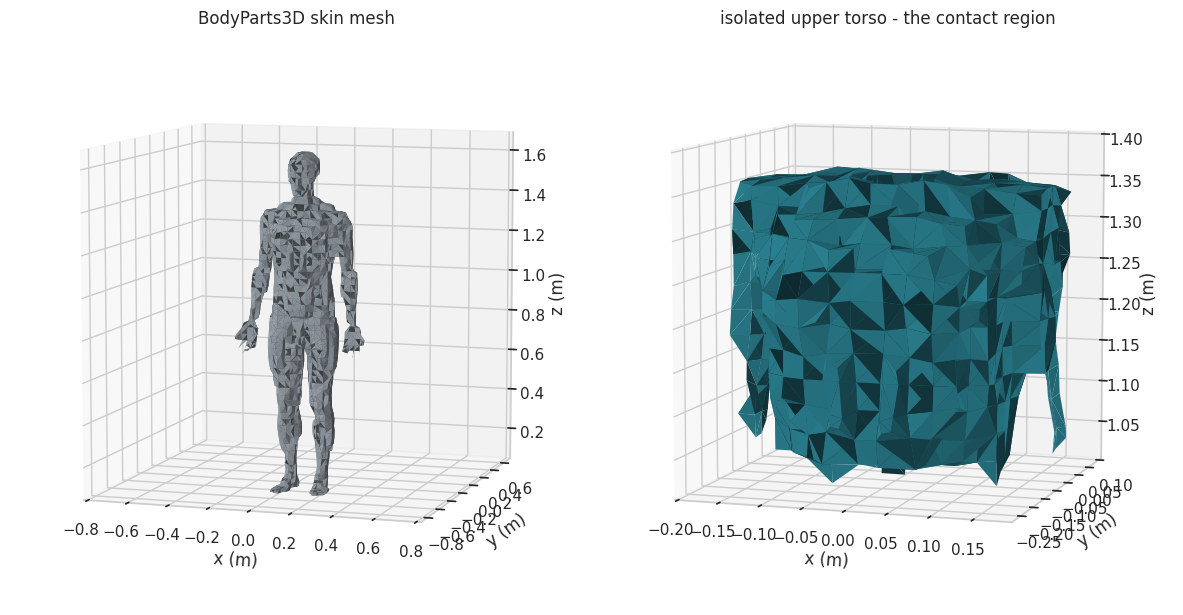

In [5]:
points, triangles = load_body_mesh(CFG)
torso = isolate_upper_torso(points, triangles, CFG)

torso_path = Path("..") / "data" / "external" / "body_mesh" / "upper-torso.obj"
meshio.write_points_cells(str(torso_path), torso.points, [("triangle", torso.triangles)])

mesh_tbl = Table(title="[bold]Body mesh -> isolated upper torso[/bold]",
                 show_header=True, header_style="bold cyan")
mesh_tbl.add_column("Mesh")
mesh_tbl.add_column("Vertices", justify="right")
mesh_tbl.add_column("Triangles", justify="right")
mesh_tbl.add_column("Measure", justify="right")
mesh_tbl.add_row("BodyParts3D skin (decimated)", str(len(points)), str(len(triangles)),
                 f"{np.ptp(points[:, 2]):.2f} m tall")
mesh_tbl.add_row("upper torso (isolated)", str(len(torso.points)), str(len(torso.triangles)),
                 f"{torso.volume * 1e3:.1f} L hull volume")
console.print(mesh_tbl)
console.print(f"isolated upper torso saved to [cyan]{torso_path}[/cyan]")

fig = plt.figure(figsize=(12, 6.5))
for idx, (pp, tt, title, colour) in enumerate([
    (points, triangles, "BodyParts3D skin mesh", "#9aa3ab"),
    (torso.points, torso.triangles, "isolated upper torso - the contact region", "#2a7f8f"),
]):
    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")
    ax.plot_trisurf(pp[:, 0], pp[:, 1], pp[:, 2], triangles=tt, color=colour, edgecolor="none")
    equal_3d(ax, pp)
    ax.view_init(elev=8, azim=-72)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIG_DIR / "03-body-mesh-torso.png", dpi=140, bbox_inches="tight")
plt.show()


## Voxelising the Torso into a FEM Solid

The finite-element model needs a *volume*, not a surface. The torso is filled to its convex hull - it is a convex barrel-like shape - and the hull volume is diced into a regular voxel grid; every voxel inside the hull becomes six tetrahedra. The result is a solid tetrahedral mesh: the body the impact will deform. The cross-section confirms it is genuinely filled, not a hollow shell.


╭───────────────────────────────────────────── Voxelised torso solid ─────────────────────────────────────────────╮
│ voxel size 22 mm    nodes 2948    tetrahedra 13698    surface triangles 2472                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

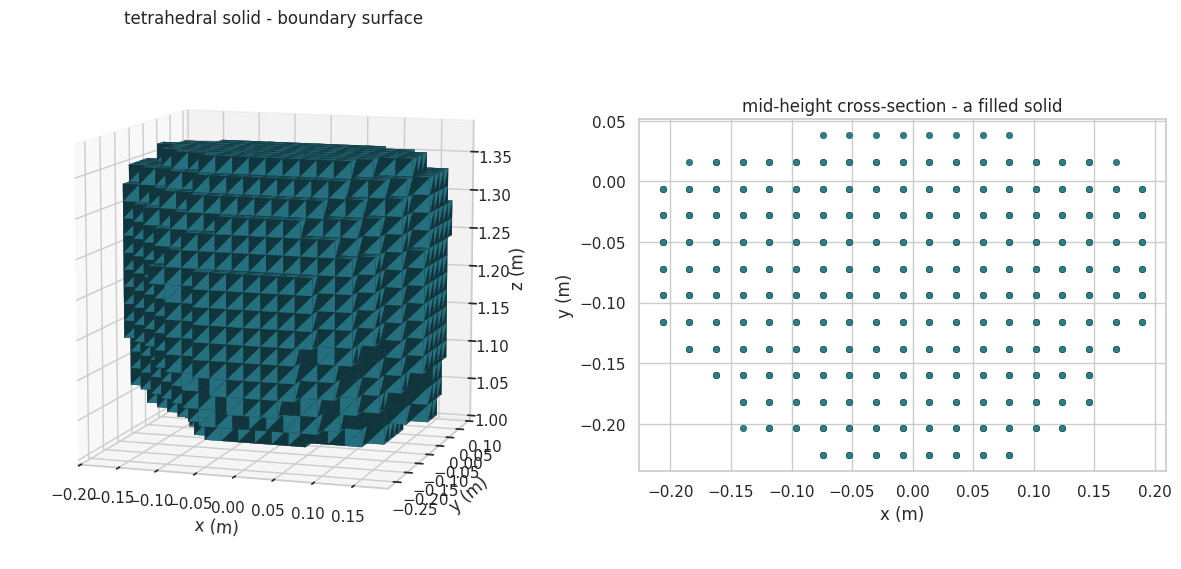

In [6]:
nodes, tets = voxelise_torso(torso, CFG)

# boundary facets - the triangular faces shared by only one tetrahedron
_faces = np.sort(np.vstack([
    tets[:, [0, 1, 2]], tets[:, [0, 1, 3]], tets[:, [0, 2, 3]], tets[:, [1, 2, 3]]
]), axis=1)
_uniq, _counts = np.unique(_faces, axis=0, return_counts=True)
boundary = _uniq[_counts == 1]
bnodes = np.unique(boundary)

console.print(Panel(
    f"voxel size [bold]{CFG.voxel_size * 1e3:.0f} mm[/bold]    "
    f"nodes [bold]{len(nodes)}[/bold]    tetrahedra [bold]{len(tets)}[/bold]    "
    f"surface triangles [bold]{len(boundary)}[/bold]",
    title="[bold green]Voxelised torso solid[/bold green]", border_style="green"))

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_trisurf(nodes[:, 0], nodes[:, 1], nodes[:, 2], triangles=boundary,
                color="#2a7f8f", edgecolor="#16323a", linewidth=0.1)
equal_3d(ax, nodes)
ax.view_init(elev=10, azim=-72)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title("tetrahedral solid - boundary surface")

ax = fig.add_subplot(1, 2, 2)
zc = nodes[:, 2].mean()
slab = np.abs(nodes[:, 2] - zc) < CFG.voxel_size
ax.scatter(nodes[slab, 0], nodes[slab, 1], s=22, color="#2a7f8f",
           edgecolor="#16323a", linewidth=0.3)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("mid-height cross-section - a filled solid")
fig.tight_layout()
fig.savefig(FIG_DIR / "03-fem-tet-mesh.png", dpi=140, bbox_inches="tight")
plt.show()


## The Deformation Modes

scikit-fem assembles the torso's 3D linear-elastic stiffness and mass matrices, and an eigensolve gives its deformation modes - the natural ways the soft-tissue solid can squash and flex. The six rigid-body modes are discarded; the elastic modes that remain sit in the tens-of-hertz band.

What matters acoustically is how much air each mode pushes - its volume velocity. A mode that changes the torso's volume moves the chest wall as a bellows and pushes air; a pure shape-shift pushes almost none. The bar colour below is that air-pushing strength.


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


             Torso deformation modes             
┏━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Mode ┃ Frequency (Hz) ┃ Air pushed |A| (cm^3) ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│    1 │           18.2 │                   8.7 │
│    2 │           21.8 │                 322.7 │
│    3 │           25.7 │                 258.6 │
│    4 │           27.1 │                 334.8 │
│    5 │           28.9 │                1305.5 │
│    6 │           29.2 │                 935.5 │
│    7 │           29.5 │                1029.2 │
│    8 │           31.5 │                2016.0 │
│    9 │           33.1 │                1176.0 │
│   10 │           34.6 │                 997.9 │
│   11 │           34.8 │                7164.0 │
│   12 │           35.6 │                6740.7 │
└──────┴────────────────┴───────────────────────┘

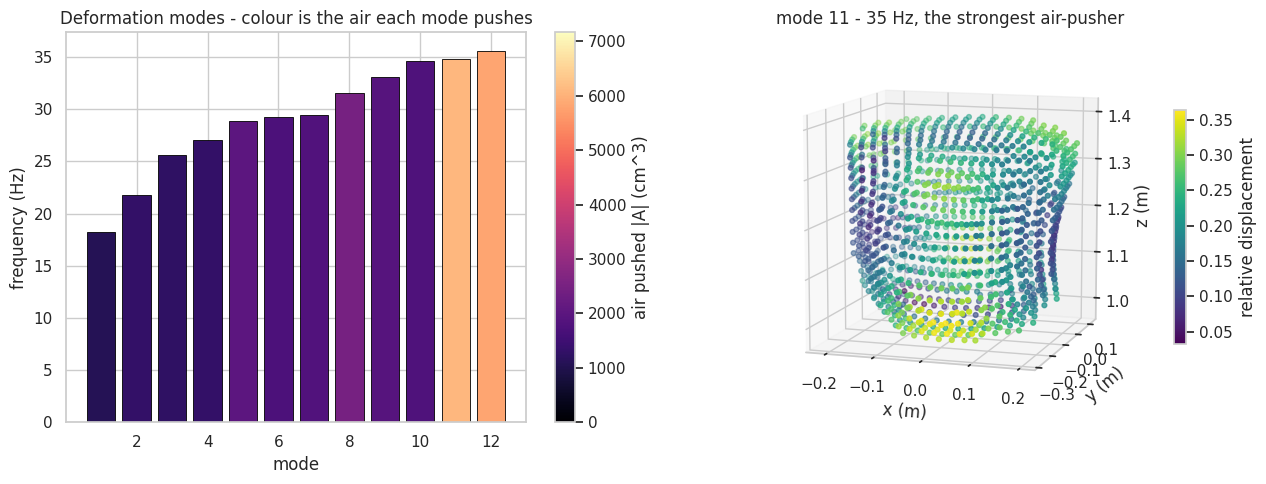

In [7]:
fem = solve_modes(nodes, tets, CFG)

modes_tbl = Table(title="[bold]Torso deformation modes[/bold]",
                  show_header=True, header_style="bold cyan")
modes_tbl.add_column("Mode", justify="right")
modes_tbl.add_column("Frequency (Hz)", justify="right")
modes_tbl.add_column("Air pushed |A| (cm^3)", justify="right")
for i, (freq, amp) in enumerate(zip(fem.frequencies, fem.volume_velocity)):
    modes_tbl.add_row(str(i + 1), f"{freq:.1f}", f"{abs(amp) * 1e6:.1f}")
console.print(modes_tbl)

loud = int(np.argmax(np.abs(fem.volume_velocity)))
vv = np.abs(fem.volume_velocity)

fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
ax.bar(np.arange(1, CFG.n_modes + 1), fem.frequencies,
       color=plt.cm.magma(0.15 + 0.7 * vv / vv.max()), edgecolor="black", lw=0.6)
ax.set_xlabel("mode")
ax.set_ylabel("frequency (Hz)")
ax.set_title("Deformation modes - colour is the air each mode pushes")
sm = plt.cm.ScalarMappable(cmap="magma", norm=plt.Normalize(0, vv.max() * 1e6))
sm.set_array([])
fig.colorbar(sm, ax=ax, label="air pushed |A| (cm^3)")

ax = fig.add_subplot(1, 2, 2, projection="3d")
shape = fem.shapes[loud]
mag = np.linalg.norm(shape, axis=1)
disp = nodes + (0.05 / mag.max()) * shape
sc = ax.scatter(disp[bnodes, 0], disp[bnodes, 1], disp[bnodes, 2],
                c=mag[bnodes], cmap="viridis", s=12)
equal_3d(ax, disp[bnodes])
ax.view_init(elev=10, azim=-72)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title(f"mode {loud + 1} - {fem.frequencies[loud]:.0f} Hz, the strongest air-pusher")
fig.colorbar(sc, ax=ax, label="relative displacement", shrink=0.6)
fig.tight_layout()
fig.savefig(FIG_DIR / "03-fem-modes.png", dpi=140, bbox_inches="tight")
plt.show()


## The Impact - the Chest Squashes

The contact force - the body's deceleration carried by the effective impacting mass - is projected onto every deformation mode at the back contact patch, and each mode is time-marched as a damped oscillator. The contact force is **not smooth**: the uneven body surface (ribs, the spine, clothing folds) engages the wall bump by bump, so the force is grained - and that graining is what keeps the thump from being a pure tone. Summing the modes back into the displacement field gives the torso at peak squash.


peak chest deflection 21.6 mm at 22 ms after first contact

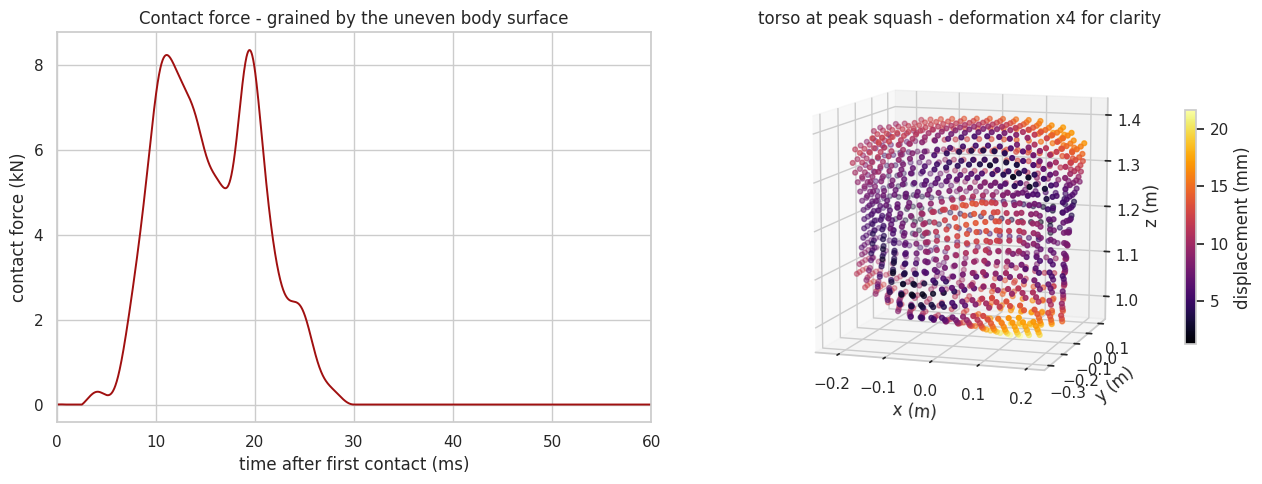

In [8]:
t, modal_q, modal_a, force = impact_response(fem, CFG)
pressure_thump = radiate_modes(fem, t, modal_a, CFG)

# reconstruct the displacement field, locate the peak squash
stride = max(1, len(t) // 400)
disp_t = np.einsum("it,inj->tnj", modal_q[:, ::stride], fem.shapes)
node_mag = np.linalg.norm(disp_t, axis=2)
peak_step = int(node_mag.max(axis=1).argmax())
peak_defl = float(node_mag.max())
peak_field = disp_t[peak_step]

console.print(
    f"peak chest deflection [bold]{peak_defl * 1e3:.1f} mm[/bold] at "
    f"{t[::stride][peak_step] * 1e3:.0f} ms after first contact"
)

fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(t * 1e3, force / 1e3, color="#a01010", lw=1.4)
ax.set_xlabel("time after first contact (ms)")
ax.set_ylabel("contact force (kN)")
ax.set_xlim(0, 60)
ax.set_title("Contact force - grained by the uneven body surface")

ax = fig.add_subplot(1, 2, 2, projection="3d")
exag = 4.0
shoved = nodes + exag * peak_field
mg = np.linalg.norm(peak_field, axis=1)
sc = ax.scatter(shoved[bnodes, 0], shoved[bnodes, 1], shoved[bnodes, 2],
                c=mg[bnodes] * 1e3, cmap="inferno", s=12)
equal_3d(ax, shoved[bnodes])
ax.view_init(elev=10, azim=-72)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_zlabel("z (m)")
ax.set_title(f"torso at peak squash - deformation x{exag:.0f} for clarity")
fig.colorbar(sc, ax=ax, label="displacement (mm)", shrink=0.6)
fig.tight_layout()
fig.savefig(FIG_DIR / "03-fem-deformation.png", dpi=140, bbox_inches="tight")
plt.show()


## The Squeezed-Air Burst

As the body's back nears the wall, the air trapped in the gap is forced out through the patch perimeter. The escape velocity climbs as the gap thins - and peaks the instant the gap seals, the "thud". Because the body surface is uneven the gap is non-uniform and the escaping flow is turbulent: the sound is a brief, broadband, **textured** burst, far higher in pitch than the body's thump. It is a compact aeroacoustic estimate - an order-of-magnitude scaling, not a resolved flow solution.


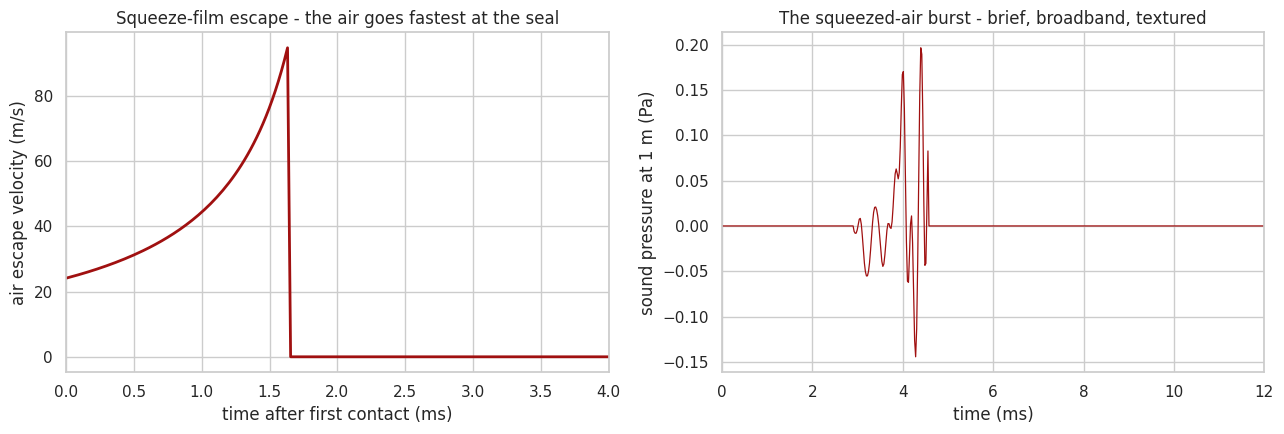

In [9]:
t_escape, pressure_escape = air_escape(CFG)

# the squeeze-film escape velocity, recomputed for the plot
perimeter = 2.0 * np.sqrt(np.pi * CFG.contact_patch_area)
raw_gap = CFG.gap_squeeze_start - CFG.v_close * t_escape
v_esc = CFG.contact_patch_area * CFG.v_close / (perimeter * np.clip(raw_gap, CFG.gap_seal, None))
v_esc[raw_gap <= CFG.gap_seal] = 0.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(t_escape * 1e3, v_esc, color="#a01010", lw=2)
ax.set_xlabel("time after first contact (ms)")
ax.set_ylabel("air escape velocity (m/s)")
ax.set_xlim(0, 4)
ax.set_title("Squeeze-film escape - the air goes fastest at the seal")

ax = axes[1]
ax.plot(t_escape * 1e3, pressure_escape, color="#a01010", lw=0.9)
ax.set_xlabel("time (ms)")
ax.set_ylabel("sound pressure at 1 m (Pa)")
ax.set_xlim(0, 12)
ax.set_title("The squeezed-air burst - brief, broadband, textured")
fig.tight_layout()
fig.savefig(FIG_DIR / "03-fem-air-escape.png", dpi=140, bbox_inches="tight")
plt.show()


## The Sound at the Microphone

The microphone hears the two summed: the low thump of the air the deforming torso pushes, and the high, textured burst of the squeezed air. The spectrum shows them in their own bands - the thump in the tens of hertz, the burst spread broadband above it. The dB ratings below are flat (peak SPL) and A-weighted (dBA, what a sound-level meter shows and what tracks loudness perception). The combined waveform is written to a WAV file with a lead-in and a loudness lift for listening.


thump   peak SPL  99.9 dB   A-weighted peak  78.8 dBA

escape  peak SPL  79.8 dB   A-weighted peak  80.1 dBA

total   peak SPL  99.9 dB   A-weighted peak  80.0 dBA

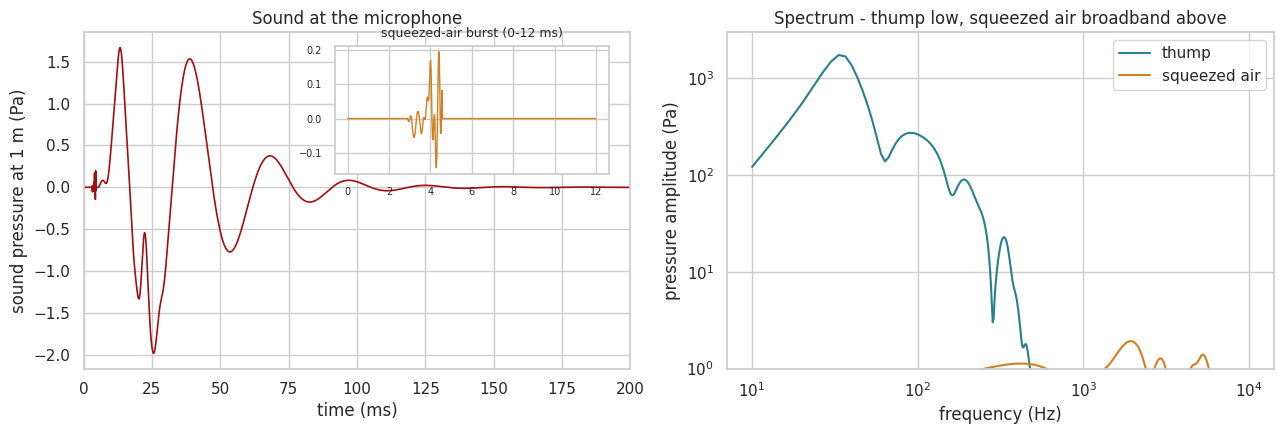

thump audio (0.8 s, lead-in + loudness lift) written to ../reports/figures/03-body-thump.wav

In [10]:
pressure = pressure_thump + pressure_escape
fs = CFG.sample_rate

# dB ratings - flat peak SPL and A-weighted (dBA)
for label, sig in [("thump", pressure_thump), ("escape", pressure_escape),
                    ("total", pressure)]:
    lv = sound_levels(sig, fs)
    console.print(
        f"[bold]{label:7s}[/bold] peak SPL [bold]{lv['peak_spl']:5.1f} dB[/bold]   "
        f"A-weighted peak [bold]{lv['peak_dba']:5.1f} dBA[/bold]"
    )

spec_thump = np.abs(np.fft.rfft(pressure_thump))
spec_escape = np.abs(np.fft.rfft(pressure_escape))
freq = np.fft.rfftfreq(len(pressure), 1.0 / fs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(t * 1e3, pressure, color="#a01010", lw=1.2)
ax.set_xlabel("time (ms)")
ax.set_ylabel("sound pressure at 1 m (Pa)")
ax.set_xlim(0, 200)
ax.set_title("Sound at the microphone")
# inset - the squeezed-air burst rides ahead of the thump
inset = ax.inset_axes([0.46, 0.58, 0.50, 0.38])
early = t * 1e3 <= 12
inset.plot(t[early] * 1e3, pressure_escape[early], color="#d08020", lw=1.0)
inset.set_title("squeezed-air burst (0-12 ms)", fontsize=9)
inset.tick_params(labelsize=7)

ax = axes[1]
band = (freq >= 10.0) & (freq <= 10000.0)
ax.semilogy(freq[band], spec_thump[band] + 1e-3, color="#2a7f8f", lw=1.5, label="thump")
ax.semilogy(freq[band], spec_escape[band] + 1e-3, color="#d08020", lw=1.5,
            label="squeezed air")
ax.set_xscale("log")
ax.set_ylim(1e0, 3e3)
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("pressure amplitude (Pa)")
ax.set_title("Spectrum - thump low, squeezed air broadband above")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03-fem-thump-and-escape.png", dpi=140, bbox_inches="tight")
plt.show()

# WAV - a 0.5 s lead-in before the impact, then a loudness lift for listening.
# The lift (peak-normalise then a tanh soft-limiter) is for audibility only;
# the physics and the dB ratings above come from the un-shaped pressure.
lead = np.zeros(int(0.5 * fs))
sound = np.concatenate([lead, pressure])
shaped = np.tanh(3.0 * sound / np.abs(sound).max())
shaped = shaped / np.abs(shaped).max() * 0.97
wav_path = FIG_DIR / "03-body-thump.wav"
wavfile.write(str(wav_path), fs, (shaped * 32767).astype(np.int16))
console.print(f"thump audio ({len(shaped) / fs:.1f} s, lead-in + loudness lift) "
              f"written to [cyan]{wav_path}[/cyan]")


## Scenario Comparison - With and Without Free Coasting

Notebook 01's kinematics does not give a single closing velocity but an envelope. The body is either propelled the whole way to the door (no free coasting, the faster bound) or released early and left to coast the last stretch (with free coasting, the slower bound). The body thump is run through the full FEM model at both bounds, so its sound level is reported for each. The dB ratings are flat peak SPL and A-weighted (dBA).

In [11]:
# the closing-velocity envelope from notebook 01's kinematics
_no_coast, _with_coast = solve_envelope(ChoreographyConfig())

# the no-coast thump is the `pressure` solved above; solve the with-coast thump
res_coast = solve_body_fem(BodyFEMConfig(v_close=_with_coast.v_close))
scenarios = [
    ("Without free coasting", _no_coast.v_close, pressure),
    ("With free coasting", _with_coast.v_close, res_coast.pressure),
]

cmp_tbl = Table(title="Body thump - sound level by kinematics scenario",
                header_style="bold", show_lines=True)
cmp_tbl.add_column("scenario", style="bold cyan")
cmp_tbl.add_column("closing velocity", justify="right")
cmp_tbl.add_column("peak SPL", justify="right")
cmp_tbl.add_column("A-weighted", justify="right")
for name, v, sig in scenarios:
    lv = sound_levels(sig, CFG.sample_rate)
    cmp_tbl.add_row(name, f"{v:.2f} m/s",
                    f"{lv['peak_spl']:.1f} dB", f"{lv['peak_dba']:.1f} dBA")
console.print(cmp_tbl)

Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


          Body thump - sound level by kinematics scenario           
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ scenario              ┃ closing velocity ┃ peak SPL ┃ A-weighted ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Without free coasting │         2.74 m/s │  99.9 dB │   80.0 dBA │
├───────────────────────┼──────────────────┼──────────┼────────────┤
│ With free coasting    │         2.35 m/s │  98.0 dB │   82.3 dBA │
└───────────────────────┴──────────────────┴──────────┴────────────┘

## Summary

- The FEM body-impact sound model lives in `henryk_simulations.corridor.bodyfem` - a library module under the corridor submodule, exercised by 22 test guards. This notebook is a thin client over its staged functions.
- The radiating surface is a **real 3D body mesh** - the BodyParts3D skin model - with the upper torso isolated and voxelised into a tetrahedral solid of roughly 2,950 nodes and 13,700 tetrahedra.
- A 3D linear-elastic finite-element model (scikit-fem) gives the torso's soft-tissue deformation modes, between about 18 and 36 Hz. The thorax is treated as compressible (the air-filled lungs), so the impact squash works the chest wall as a bellows; peak chest deflection is about **2 cm**.
- The body is never a sound source. The microphone hears two pushed-air components: the **thump** - the air the deforming torso pushes, a low compact monopole - and the **squeezed-air burst** - the air forced out of the closing wall-body gap, brief and broadband.
- The uneven body surface textures both: it grains the contact force that drives the thump, and it makes the escaping air turbulent. Neither component is a clean tone.
- The body thump is run at both ends of notebook 01's closing-velocity envelope. Without free coasting (2.74 m/s) it reaches about **100 dB** peak SPL and **80 dBA**; with free coasting (2.35 m/s) about **98 dB** and **82 dBA**. A clean, smooth thump would sit near 60 dBA, nearly all sub-bass; the uneven-surface texture, graining the contact force and roughening the squeezed-air burst, is what lifts the sound into the band the meter and the ear register.
- The door's own sound is out of scope: the wall is rigid and does not radiate.
